In [1]:
import sys
import os

print("Python executable:")
print(sys.executable)

print("\nCurrent working directory:")
print(os.getcwd())

print("\nPython version:")
print(sys.version)

Python executable:
C:\Users\SAIFUL ISLAM\OneDrive\Desktop\CSE445-Project\venv\python.exe

Current working directory:
C:\Users\SAIFUL ISLAM\OneDrive\Desktop\CSE445-Project

Python version:
3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Random Forest libraries imported successfully.")

Random Forest libraries imported successfully.


In [3]:
train_df = pd.read_csv(
    "model_training/Dataset/train_features.csv"
)

val_df = pd.read_csv(
    "model_training/Dataset/validation_features.csv"
)

test_df = pd.read_csv(
    "model_training/Dataset/test_features.csv"
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (15140, 25)
Validation shape: (4321, 25)
Test shape: (2153, 25)


In [4]:
feature_cols = [
    "head_drop",
    "shoulder_drop",
    "head_velocity_mean",
    "head_velocity_max",
    "torso_tilt_std",
    "torso_tilt_range",
    "lateral_sway_range",
    "sway_direction_changes",
    "min_hand_to_chest",
    "hand_to_chest_drop",
    "accel_slope",
    "vertical_ratio",
    "max_downward_vel",
    "ending_tilt",
    "tilt_net_change",
    "knee_bend_min",
    "elbow_angle_min",
    "hand_dwell_frames",
    "foot_sep_std",
    "time_to_min_drop"
]

print("Number of model features:", len(feature_cols))

train_df["stage1_label"] = (
    train_df["label"] != "Normal Activity"
).astype(int)

val_df["stage1_label"] = (
    val_df["label"] != "Normal Activity"
).astype(int)

test_df["stage1_label"] = (
    test_df["label"] != "Normal Activity"
).astype(int)

print("\nStage 1 training distribution:")
print(train_df["stage1_label"].value_counts().sort_index())

print("\nStage 1 validation distribution:")
print(val_df["stage1_label"].value_counts().sort_index())

print("\nStage 1 test distribution:")
print(test_df["stage1_label"].value_counts().sort_index())

Number of model features: 20

Stage 1 training distribution:
stage1_label
0    7185
1    7955
Name: count, dtype: int64

Stage 1 validation distribution:
stage1_label
0    2060
1    2261
Name: count, dtype: int64

Stage 1 test distribution:
stage1_label
0    1030
1    1123
Name: count, dtype: int64


In [5]:
X_train_stage1 = train_df[feature_cols]
y_train_stage1 = train_df["stage1_label"]

X_val_stage1 = val_df[feature_cols]
y_val_stage1 = val_df["stage1_label"]

X_test_stage1 = test_df[feature_cols]
y_test_stage1 = test_df["stage1_label"]

print("X_train_stage1:", X_train_stage1.shape)
print("y_train_stage1:", y_train_stage1.shape)

print("\nX_val_stage1:", X_val_stage1.shape)
print("y_val_stage1:", y_val_stage1.shape)

print("\nX_test_stage1:", X_test_stage1.shape)
print("y_test_stage1:", y_test_stage1.shape)

X_train_stage1: (15140, 20)
y_train_stage1: (15140,)

X_val_stage1: (4321, 20)
y_val_stage1: (4321,)

X_test_stage1: (2153, 20)
y_test_stage1: (2153,)


In [6]:
stage1_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=445,
    n_jobs=-1
)

stage1_rf.fit(
    X_train_stage1,
    y_train_stage1
)

print("Stage 1 Random Forest trained successfully.")

Stage 1 Random Forest trained successfully.


In [7]:
y_val_pred_stage1_rf = stage1_rf.predict(
    X_val_stage1
)

stage1_rf_accuracy = accuracy_score(
    y_val_stage1,
    y_val_pred_stage1_rf
)

stage1_rf_precision = precision_score(
    y_val_stage1,
    y_val_pred_stage1_rf
)

stage1_rf_recall = recall_score(
    y_val_stage1,
    y_val_pred_stage1_rf
)

stage1_rf_f1 = f1_score(
    y_val_stage1,
    y_val_pred_stage1_rf
)

print("STAGE 1 RANDOM FOREST VALIDATION RESULTS")
print("=" * 50)

print("\nAccuracy:")
print(stage1_rf_accuracy)

print("\nPrecision for Abnormal:")
print(stage1_rf_precision)

print("\nRecall for Abnormal:")
print(stage1_rf_recall)

print("\nF1 Score:")
print(stage1_rf_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_val_stage1,
        y_val_pred_stage1_rf,
        target_names=[
            "Normal",
            "Abnormal"
        ]
    )
)

print("\nConfusion Matrix:")
stage1_rf_cm = confusion_matrix(
    y_val_stage1,
    y_val_pred_stage1_rf
)

print(stage1_rf_cm)

STAGE 1 RANDOM FOREST VALIDATION RESULTS

Accuracy:
0.8037491321453367

Precision for Abnormal:
0.8227501142074006

Recall for Abnormal:
0.7965501990269792

F1 Score:
0.809438202247191

Classification Report:
              precision    recall  f1-score   support

      Normal       0.78      0.81      0.80      2060
    Abnormal       0.82      0.80      0.81      2261

    accuracy                           0.80      4321
   macro avg       0.80      0.80      0.80      4321
weighted avg       0.80      0.80      0.80      4321


Confusion Matrix:
[[1672  388]
 [ 460 1801]]


In [8]:
stage1_rf_prob = stage1_rf.predict_proba(
    X_val_stage1
)[:, 1]

thresholds = [
    0.50,
    0.45,
    0.40,
    0.35,
    0.30
]

print(
    f"{'Threshold':<12}"
    f"{'Accuracy':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
    f"{'FN':<8}"
    f"{'FP':<8}"
)

for threshold in thresholds:

    predictions = (
        stage1_rf_prob >= threshold
    ).astype(int)

    acc = accuracy_score(
        y_val_stage1,
        predictions
    )

    precision = precision_score(
        y_val_stage1,
        predictions
    )

    recall = recall_score(
        y_val_stage1,
        predictions
    )

    f1 = f1_score(
        y_val_stage1,
        predictions
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val_stage1,
        predictions
    ).ravel()

    print(
        f"{threshold:<12.2f}"
        f"{acc:<12.4f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
        f"{fn:<8}"
        f"{fp:<8}"
    )

Threshold   Accuracy    Precision   Recall      F1          FN      FP      
0.50        0.8049      0.8214      0.8014      0.8113      449     394     
0.45        0.8021      0.7910      0.8452      0.8172      350     505     
0.40        0.8007      0.7696      0.8837      0.8227      263     598     
0.35        0.7906      0.7449      0.9120      0.8200      199     706     
0.30        0.7744      0.7166      0.9407      0.8135      134     841     


In [9]:
stage1_rf_configs = [
    {
        "name": "Baseline",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    {
        "name": "More Trees",
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    {
        "name": "Depth 15",
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_leaf": 1
    },
    {
        "name": "Depth 10",
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_leaf": 1
    },
    {
        "name": "Leaf 2",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2
    }
]

RF_STAGE1_THRESHOLD = 0.40

print(
    f"{'Model':<15}"
    f"{'Accuracy':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<12}"
    f"{'FN':<8}"
    f"{'FP':<8}"
)

stage1_rf_tuning_results = []

for config in stage1_rf_configs:

    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        class_weight="balanced",
        random_state=445,
        n_jobs=-1
    )

    model.fit(
        X_train_stage1,
        y_train_stage1
    )

    probabilities = model.predict_proba(
        X_val_stage1
    )[:, 1]

    predictions = (
        probabilities >= RF_STAGE1_THRESHOLD
    ).astype(int)

    acc = accuracy_score(
        y_val_stage1,
        predictions
    )

    precision = precision_score(
        y_val_stage1,
        predictions
    )

    recall = recall_score(
        y_val_stage1,
        predictions
    )

    f1 = f1_score(
        y_val_stage1,
        predictions
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val_stage1,
        predictions
    ).ravel()

    stage1_rf_tuning_results.append(
        (
            config,
            model,
            acc,
            precision,
            recall,
            f1,
            fn,
            fp
        )
    )

    print(
        f"{config['name']:<15}"
        f"{acc:<12.4f}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
        f"{fn:<8}"
        f"{fp:<8}"
    )

Model          Accuracy    Precision   Recall      F1          FN      FP      
Baseline       0.8007      0.7696      0.8837      0.8227      263     598     
More Trees     0.8005      0.7698      0.8828      0.8224      265     597     
Depth 15       0.8065      0.7763      0.8854      0.8273      259     577     
Depth 10       0.7903      0.7621      0.8713      0.8130      291     615     
Leaf 2         0.8010      0.7725      0.8784      0.8220      275     585     


In [10]:
stage1_rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=445,
    n_jobs=-1
)

stage1_rf_final.fit(
    X_train_stage1,
    y_train_stage1
)

RF_STAGE1_THRESHOLD = 0.40

val_stage1_rf_prob = stage1_rf_final.predict_proba(
    X_val_stage1
)[:, 1]

val_stage1_rf_pred = (
    val_stage1_rf_prob >= RF_STAGE1_THRESHOLD
).astype(int)

print("FINAL STAGE 1 RANDOM FOREST RESULTS")
print("=" * 50)

print("\nAccuracy:")
print(
    accuracy_score(
        y_val_stage1,
        val_stage1_rf_pred
    )
)

print("\nPrecision for Abnormal:")
print(
    precision_score(
        y_val_stage1,
        val_stage1_rf_pred
    )
)

print("\nRecall for Abnormal:")
print(
    recall_score(
        y_val_stage1,
        val_stage1_rf_pred
    )
)

print("\nF1 Score:")
print(
    f1_score(
        y_val_stage1,
        val_stage1_rf_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val_stage1,
        val_stage1_rf_pred,
        target_names=[
            "Normal",
            "Abnormal"
        ]
    )
)

print("\nConfusion Matrix:")
stage1_rf_final_cm = confusion_matrix(
    y_val_stage1,
    val_stage1_rf_pred
)

print(stage1_rf_final_cm)

FINAL STAGE 1 RANDOM FOREST RESULTS

Accuracy:
0.8065262670678084

Precision for Abnormal:
0.7762698720434277

Recall for Abnormal:
0.8854489164086687

F1 Score:
0.8272727272727273

Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.72      0.78      2060
    Abnormal       0.78      0.89      0.83      2261

    accuracy                           0.81      4321
   macro avg       0.81      0.80      0.80      4321
weighted avg       0.81      0.81      0.80      4321


Confusion Matrix:
[[1483  577]
 [ 259 2002]]


In [11]:
train_stage2 = train_df[
    train_df["label"] != "Normal Activity"
].copy()

val_stage2 = val_df[
    val_df["label"] != "Normal Activity"
].copy()

test_stage2 = test_df[
    test_df["label"] != "Normal Activity"
].copy()

print("Stage 2 training distribution:")
print(train_stage2["label"].value_counts())

print("\nStage 2 validation distribution:")
print(val_stage2["label"].value_counts())

print("\nStage 2 test distribution:")
print(test_stage2["label"].value_counts())

print("\nShapes:")
print("Train:", train_stage2.shape)
print("Validation:", val_stage2.shape)
print("Test:", test_stage2.shape)

Stage 2 training distribution:
label
Staggering/Unbalanced Movement    3684
Touch Chest                       2425
Falling Down                      1846
Name: count, dtype: int64

Stage 2 validation distribution:
label
Staggering/Unbalanced Movement    1052
Touch Chest                        684
Falling Down                       525
Name: count, dtype: int64

Stage 2 test distribution:
label
Staggering/Unbalanced Movement    510
Touch Chest                       346
Falling Down                      267
Name: count, dtype: int64

Shapes:
Train: (7955, 26)
Validation: (2261, 26)
Test: (1123, 26)


In [12]:
X_train_stage2 = train_stage2[feature_cols]
y_train_stage2 = train_stage2["label"]

X_val_stage2 = val_stage2[feature_cols]
y_val_stage2 = val_stage2["label"]

X_test_stage2 = test_stage2[feature_cols]
y_test_stage2 = test_stage2["label"]

print("X_train_stage2:", X_train_stage2.shape)
print("y_train_stage2:", y_train_stage2.shape)

print("\nX_val_stage2:", X_val_stage2.shape)
print("y_val_stage2:", y_val_stage2.shape)

print("\nX_test_stage2:", X_test_stage2.shape)
print("y_test_stage2:", y_test_stage2.shape)

print("\nStage 2 classes:")
print(sorted(y_train_stage2.unique()))

X_train_stage2: (7955, 20)
y_train_stage2: (7955,)

X_val_stage2: (2261, 20)
y_val_stage2: (2261,)

X_test_stage2: (1123, 20)
y_test_stage2: (1123,)

Stage 2 classes:
['Falling Down', 'Staggering/Unbalanced Movement', 'Touch Chest']


In [13]:
stage2_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=445,
    n_jobs=-1
)

stage2_rf.fit(
    X_train_stage2,
    y_train_stage2
)

print("Stage 2 Random Forest trained successfully.")

Stage 2 Random Forest trained successfully.


In [14]:
y_val_pred_stage2_rf = stage2_rf.predict(
    X_val_stage2
)

stage2_rf_accuracy = accuracy_score(
    y_val_stage2,
    y_val_pred_stage2_rf
)

stage2_rf_macro_f1 = f1_score(
    y_val_stage2,
    y_val_pred_stage2_rf,
    average="macro"
)

print("STAGE 2 RANDOM FOREST VALIDATION RESULTS")
print("=" * 50)

print("\nAccuracy:")
print(stage2_rf_accuracy)

print("\nMacro F1:")
print(stage2_rf_macro_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_val_stage2,
        y_val_pred_stage2_rf
    )
)

print("\nConfusion Matrix:")

stage2_rf_cm = confusion_matrix(
    y_val_stage2,
    y_val_pred_stage2_rf,
    labels=[
        "Falling Down",
        "Staggering/Unbalanced Movement",
        "Touch Chest"
    ]
)

print(stage2_rf_cm)

STAGE 2 RANDOM FOREST VALIDATION RESULTS

Accuracy:
0.8226448474126493

Macro F1:
0.8131310907576296

Classification Report:
                                precision    recall  f1-score   support

                  Falling Down       0.70      0.80      0.75       525
Staggering/Unbalanced Movement       0.86      0.84      0.85      1052
                   Touch Chest       0.87      0.81      0.84       684

                      accuracy                           0.82      2261
                     macro avg       0.81      0.82      0.81      2261
                  weighted avg       0.83      0.82      0.82      2261


Confusion Matrix:
[[419  72  34]
 [116 885  51]
 [ 61  67 556]]


In [15]:
stage2_rf_configs = [
    {
        "name": "Baseline",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "More Trees",
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "Depth 15",
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "Depth 10",
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "Leaf 2",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    }
]

print(
    f"{'Model':<15}"
    f"{'Accuracy':<12}"
    f"{'Macro F1':<12}"
    f"{'Fall Recall':<14}"
    f"{'Stagger Recall':<16}"
    f"{'Touch Recall':<14}"
)

stage2_rf_tuning_results = []

for config in stage2_rf_configs:

    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        max_features=config["max_features"],
        class_weight="balanced",
        random_state=445,
        n_jobs=-1
    )

    model.fit(
        X_train_stage2,
        y_train_stage2
    )

    predictions = model.predict(
        X_val_stage2
    )

    acc = accuracy_score(
        y_val_stage2,
        predictions
    )

    macro_f1 = f1_score(
        y_val_stage2,
        predictions,
        average="macro"
    )

    recalls = recall_score(
        y_val_stage2,
        predictions,
        labels=[
            "Falling Down",
            "Staggering/Unbalanced Movement",
            "Touch Chest"
        ],
        average=None
    )

    stage2_rf_tuning_results.append(
        (
            config,
            model,
            acc,
            macro_f1,
            recalls
        )
    )

    print(
        f"{config['name']:<15}"
        f"{acc:<12.4f}"
        f"{macro_f1:<12.4f}"
        f"{recalls[0]:<14.4f}"
        f"{recalls[1]:<16.4f}"
        f"{recalls[2]:<14.4f}"
    )

Model          Accuracy    Macro F1    Fall Recall   Stagger Recall  Touch Recall  
Baseline       0.8226      0.8131      0.7981        0.8413          0.8129        
More Trees     0.8226      0.8131      0.8000        0.8384          0.8158        
Depth 15       0.8209      0.8111      0.8000        0.8356          0.8143        
Depth 10       0.8209      0.8120      0.8210        0.8279          0.8099        
Leaf 2         0.8226      0.8129      0.8114        0.8375          0.8085        


In [16]:
stage2_rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=445,
    n_jobs=-1
)

stage2_rf_final.fit(
    X_train_stage2,
    y_train_stage2
)

val_stage2_rf_pred = stage2_rf_final.predict(
    X_val_stage2
)

print("FINAL STAGE 2 RANDOM FOREST RESULTS")
print("=" * 50)

print("\nAccuracy:")
print(
    accuracy_score(
        y_val_stage2,
        val_stage2_rf_pred
    )
)

print("\nMacro F1:")
print(
    f1_score(
        y_val_stage2,
        val_stage2_rf_pred,
        average="macro"
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val_stage2,
        val_stage2_rf_pred
    )
)

print("\nConfusion Matrix:")

stage2_rf_final_cm = confusion_matrix(
    y_val_stage2,
    val_stage2_rf_pred,
    labels=[
        "Falling Down",
        "Staggering/Unbalanced Movement",
        "Touch Chest"
    ]
)

print(stage2_rf_final_cm)

FINAL STAGE 2 RANDOM FOREST RESULTS

Accuracy:
0.820875718708536

Macro F1:
0.8120130853868558

Classification Report:
                                precision    recall  f1-score   support

                  Falling Down       0.68      0.82      0.75       525
Staggering/Unbalanced Movement       0.88      0.83      0.85      1052
                   Touch Chest       0.87      0.81      0.84       684

                      accuracy                           0.82      2261
                     macro avg       0.81      0.82      0.81      2261
                  weighted avg       0.83      0.82      0.82      2261


Confusion Matrix:
[[431  60  34]
 [132 871  49]
 [ 69  61 554]]


In [17]:
rf_final_test_predictions = []

test_stage1_rf_prob = stage1_rf_final.predict_proba(
    X_test_stage1
)[:, 1]

for i in range(len(X_test_stage1)):

    if test_stage1_rf_prob[i] < RF_STAGE1_THRESHOLD:

        rf_final_test_predictions.append(
            "Normal Activity"
        )

    else:

        row = X_test_stage1.iloc[[i]]

        stage2_prediction = stage2_rf_final.predict(
            row
        )[0]

        rf_final_test_predictions.append(
            stage2_prediction
        )

print(
    "Total Random Forest final predictions:",
    len(rf_final_test_predictions)
)

print(
    "Total test samples:",
    len(test_df)
)

Total Random Forest final predictions: 2153
Total test samples: 2153


In [18]:
rf_final_test_predictions = np.array(
    rf_final_test_predictions
)

rf_final_labels = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

print("FINAL RANDOM FOREST END-TO-END TEST RESULTS")
print("=" * 60)

print("\nOverall Test Accuracy:")
rf_test_accuracy = accuracy_score(
    test_df["label"],
    rf_final_test_predictions
)
print(rf_test_accuracy)

print("\nMacro Precision:")
rf_test_precision = precision_score(
    test_df["label"],
    rf_final_test_predictions,
    average="macro"
)
print(rf_test_precision)

print("\nMacro Recall:")
rf_test_recall = recall_score(
    test_df["label"],
    rf_final_test_predictions,
    average="macro"
)
print(rf_test_recall)

print("\nMacro F1:")
rf_test_f1 = f1_score(
    test_df["label"],
    rf_final_test_predictions,
    average="macro"
)
print(rf_test_f1)

print("\nClassification Report:")
print(
    classification_report(
        test_df["label"],
        rf_final_test_predictions,
        labels=rf_final_labels
    )
)

print("\nConfusion Matrix:")

rf_final_cm = confusion_matrix(
    test_df["label"],
    rf_final_test_predictions,
    labels=rf_final_labels
)

print(rf_final_cm)

FINAL RANDOM FOREST END-TO-END TEST RESULTS

Overall Test Accuracy:
0.7468648397584765

Macro Precision:
0.7088425961968505

Macro Recall:
0.7460704467474405

Macro F1:
0.7240878740275721

Classification Report:
                                precision    recall  f1-score   support

               Normal Activity       0.84      0.73      0.78      1030
                  Falling Down       0.60      0.69      0.64       267
Staggering/Unbalanced Movement       0.75      0.81      0.78       510
                   Touch Chest       0.64      0.76      0.70       346

                      accuracy                           0.75      2153
                     macro avg       0.71      0.75      0.72      2153
                  weighted avg       0.76      0.75      0.75      2153


Confusion Matrix:
[[749  71  94 116]
 [ 54 184  22   7]
 [ 35  41 412  22]
 [ 50  13  20 263]]


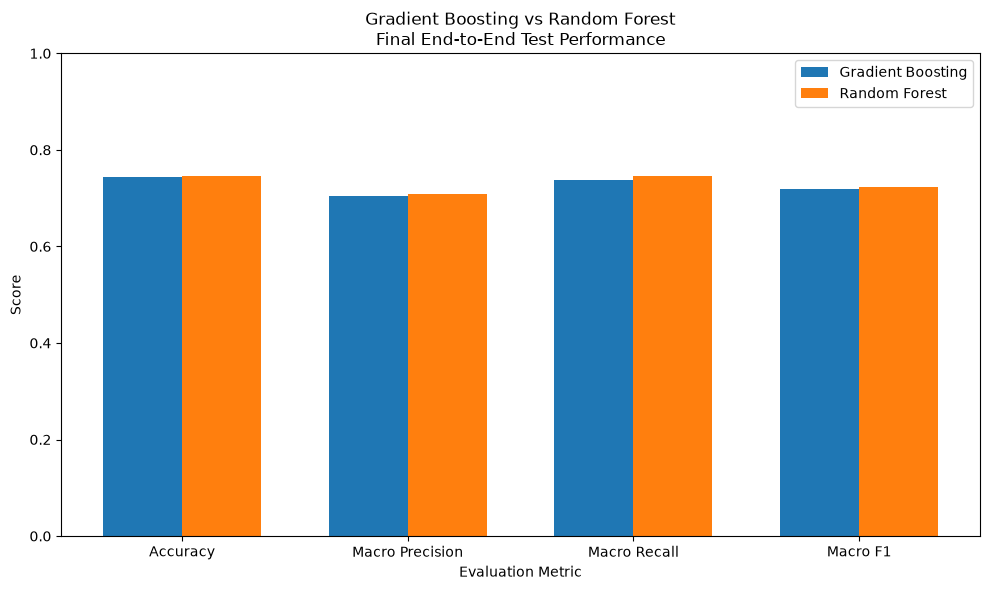

In [19]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

gradient_boosting_scores = [
    0.7445,
    0.7052,
    0.7376,
    0.7189
]

random_forest_scores = [
    rf_test_accuracy,
    rf_test_precision,
    rf_test_recall,
    rf_test_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    gradient_boosting_scores,
    width,
    label="Gradient Boosting"
)

plt.bar(
    x + width / 2,
    random_forest_scores,
    width,
    label="Random Forest"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title(
    "Gradient Boosting vs Random Forest\n"
    "Final End-to-End Test Performance"
)

plt.xticks(
    x,
    metrics
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()
plt.show()

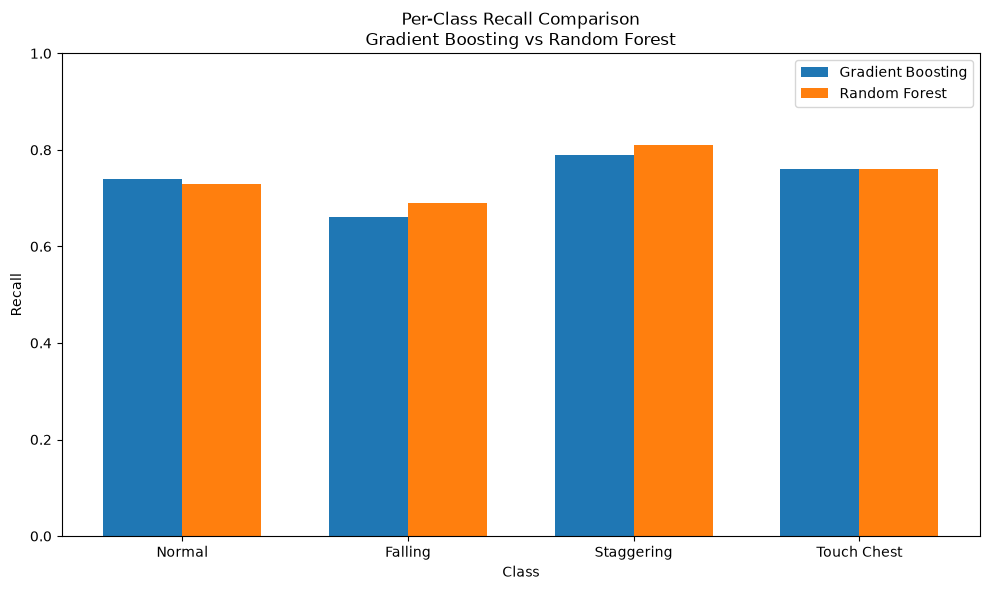

In [20]:
classes = [
    "Normal",
    "Falling",
    "Staggering",
    "Touch Chest"
]

gradient_boosting_recall = [
    0.74,
    0.66,
    0.79,
    0.76
]

random_forest_recall = [
    0.73,
    0.69,
    0.81,
    0.76
]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    gradient_boosting_recall,
    width,
    label="Gradient Boosting"
)

plt.bar(
    x + width / 2,
    random_forest_recall,
    width,
    label="Random Forest"
)

plt.xlabel("Class")
plt.ylabel("Recall")
plt.title(
    "Per-Class Recall Comparison\n"
    "Gradient Boosting vs Random Forest"
)

plt.xticks(
    x,
    classes
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()
plt.show()

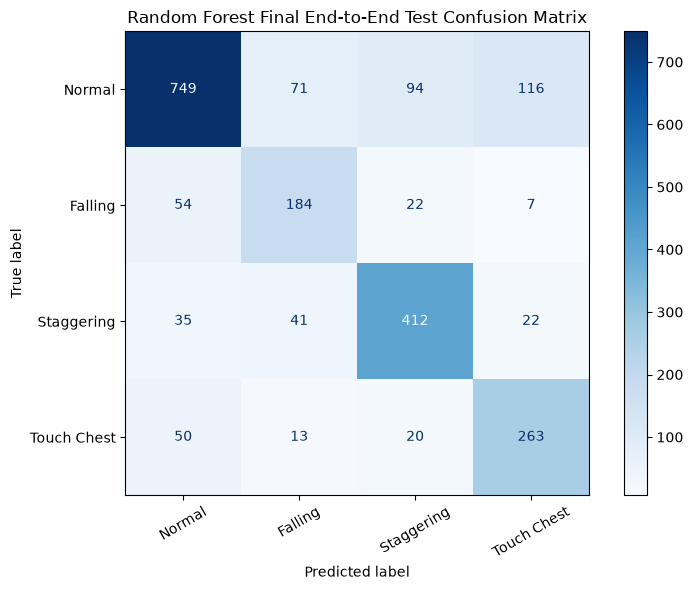

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

rf_display_labels = [
    "Normal",
    "Falling",
    "Staggering",
    "Touch Chest"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_final_cm,
    display_labels=rf_display_labels
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Final End-to-End Test Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [22]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    stage1_rf_final,
    "models/stage1_random_forest.joblib"
)

joblib.dump(
    stage2_rf_final,
    "models/stage2_random_forest.joblib"
)

rf_config = {
    "feature_cols": feature_cols,
    "stage1_threshold": RF_STAGE1_THRESHOLD,

    "stage1_classes": {
        0: "Normal Activity",
        1: "Abnormal"
    },

    "stage2_classes": list(stage2_rf_final.classes_),

    "stage1_parameters": stage1_rf_final.get_params(),
    "stage2_parameters": stage2_rf_final.get_params()
}

joblib.dump(
    rf_config,
    "models/random_forest_config.joblib"
)

print("Random Forest models saved successfully.")

print("\nFiles created:")
for file in os.listdir("models"):
    if "random_forest" in file:
        print("-", file)

Random Forest models saved successfully.

Files created:
- random_forest_config.joblib
- stage1_random_forest.joblib
- stage2_random_forest.joblib


In [23]:
loaded_stage1_rf = joblib.load(
    "models/stage1_random_forest.joblib"
)

loaded_stage2_rf = joblib.load(
    "models/stage2_random_forest.joblib"
)

loaded_rf_config = joblib.load(
    "models/random_forest_config.joblib"
)

print("Random Forest models loaded successfully.")

print("\nSaved Stage 1 threshold:")
print(loaded_rf_config["stage1_threshold"])

print("\nSaved number of features:")
print(len(loaded_rf_config["feature_cols"]))

print("\nSaved Stage 2 classes:")
print(loaded_rf_config["stage2_classes"])

Random Forest models loaded successfully.

Saved Stage 1 threshold:
0.4

Saved number of features:
20

Saved Stage 2 classes:
['Falling Down', 'Staggering/Unbalanced Movement', 'Touch Chest']


In [24]:
sample_X = X_test_stage1.iloc[:10]

original_stage1_rf_prob = stage1_rf_final.predict_proba(
    sample_X
)[:, 1]

loaded_stage1_rf_prob = loaded_stage1_rf.predict_proba(
    sample_X
)[:, 1]

print("Stage 1 probabilities identical:")
print(
    np.allclose(
        original_stage1_rf_prob,
        loaded_stage1_rf_prob
    )
)

original_stage2_rf_pred = stage2_rf_final.predict(
    sample_X
)

loaded_stage2_rf_pred = loaded_stage2_rf.predict(
    sample_X
)

print("\nStage 2 predictions identical:")
print(
    np.array_equal(
        original_stage2_rf_pred,
        loaded_stage2_rf_pred
    )
)

print("\nOriginal Stage 2 predictions:")
print(original_stage2_rf_pred)

print("\nLoaded Stage 2 predictions:")
print(loaded_stage2_rf_pred)

Stage 1 probabilities identical:
True

Stage 2 predictions identical:
True

Original Stage 2 predictions:
['Touch Chest' 'Touch Chest' 'Touch Chest' 'Touch Chest' 'Touch Chest'
 'Touch Chest' 'Touch Chest' 'Touch Chest' 'Touch Chest' 'Touch Chest']

Loaded Stage 2 predictions:
['Touch Chest' 'Touch Chest' 'Touch Chest' 'Touch Chest' 'Touch Chest'
 'Touch Chest' 'Touch Chest' 'Touch Chest' 'Touch Chest' 'Touch Chest']
